### Author: Max Vo

In [2]:
import numpy as np
import pandas as pd 

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
current_dir = Path.cwd()

## Data Loading and Dummy Variable Creation for Categorical Features

In [ ]:
ln -s ../Finalized_Feature_Sets/model_data_simple.parquet model_data_simple.parquet

ln -s ../Finalized_Feature_Sets/non-imputed_data.parquet non-imputed_data.parquet

In [3]:
model_data_simple = pd.read_parquet(
    "model_data_simple.parquet",
    engine="pyarrow"
    )

In [4]:
# confirm train_dummy split proportion

model_data_simple["train_dummy"].value_counts(normalize=True)

train_dummy
1    0.749412
0    0.250588
Name: proportion, dtype: float64

In [9]:
model_data_simple.shape

(1700, 31)

In [7]:
feature_cols = model_data_simple.columns.drop(["ZSN", "train_dummy"])

x_train = model_data_simple.loc[model_data_simple["train_dummy"] == 1, feature_cols]
y_train = model_data_simple.loc[model_data_simple["train_dummy"] == 1, "ZSN"]

x_test = model_data_simple.loc[model_data_simple["train_dummy"] == 0, feature_cols]
y_test = model_data_simple.loc[model_data_simple["train_dummy"] == 0, "ZSN"]

In [ ]:
# one hot encode categorical features for tree-based models (no need to drop first category since trees are not affected by multicollinearity)
x_train = pd.get_dummies(x_train, drop_first=False)
x_test = pd.get_dummies(x_test, drop_first=False)

x_train, x_test = x_train.align(
    x_test,
    join="left",
    axis=1,
    fill_value=0
)
print(set(x_train.columns) - set(x_test.columns)) # should be empty set

set()


In [12]:
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)
print(x_train.columns.tolist())

(1274, 46) (1274,)
(426, 46) (426,)
['AGE', 'SEX', 'INF_ANAM', 'IBS_POST', 'GB', 'endocr_01', 'S_AD_ORIT', 'D_AD_ORIT', 'O_L_POST', 'MP_TP_POST', 'NA_BLOOD', 'K_BLOOD', 'L_BLOOD', 'ant_im', 'lat_im', 'inf_im', 'post_im', 'ritm_ecg_p_01', 'any_pulmonary_disease', 'any_arrhythmia', 'any_conduction_block', 'ROE_log', 'ALT_BLOOD_log', 'AST_BLOOD_log', 'ZSN_A_recode_mild', 'ZSN_A_recode_missing', 'ZSN_A_recode_moderate_severe', 'ZSN_A_recode_none', 'time_bin_early', 'time_bin_intermediate', 'time_bin_late', 'time_bin_missing', 'angina_timing_intermediate', 'angina_timing_missing', 'angina_timing_never', 'angina_timing_recent', 'angina_timing_remote', 'angina_severity_missing', 'angina_severity_moderate', 'angina_severity_none', 'angina_severity_other', 'htn_duration_long', 'htn_duration_medium', 'htn_duration_missing', 'htn_duration_none', 'htn_duration_short']


https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

### Important Hyperparameters to tune:

* max_depth: The maximum depth of the tree
* min_samples_leaf: The minimum number of samples required to be at a leaf node
* max_features: The number of features to consider when looking for the best split

### Additional Stability Parameters:

* n_estimators: The number of trees in the forest
* class_weight: due to class imbalance ~ may set to "balanced"

### Exploratory Grid for Hyperparameter Tuning

In [13]:
# Exploratory Grid for Hyperparameter Tuning

param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [5, 8, 12, None],
    "min_samples_leaf": [1, 5, 10],
    "max_features": ["sqrt", "log2", 0.5],
    "class_weight": [None, "balanced"]
}

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, average_precision_score

rf = RandomForestClassifier(
    random_state=321,
    n_jobs = 8
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=321
)

rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=50,
    scoring="average_precision",   # PR AUC
    cv=cv,
    n_jobs=8,
    random_state=321,
    verbose=1,
    return_train_score=True
)

## Exploratory Cross Validation for Hyperparameter Tuning (using PR AUC as scoring metric)

In [15]:
rf_search.fit(x_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...dom_state=321)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'class_weight': [None, 'balanced'], 'max_depth': [5, 8, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",8
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that 

In [16]:
print("Best PR AUC:", rf_search.best_score_)
print("Best params:", rf_search.best_params_)

Best PR AUC: 0.4874882299852
Best params: {'n_estimators': 200, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': 5, 'class_weight': None}


In [18]:
rf_results = pd.DataFrame(rf_search.cv_results_)

rf_results[["mean_train_score", "mean_test_score"]].head()

,mean_train_score,mean_test_score
0,0.949462,0.465592
1,0.796167,0.478326
2,0.801175,0.465549
3,0.830937,0.481001
4,0.927870,0.469417


In [ ]:
rf_results = pd.DataFrame(rf_search.cv_results_)

cols = [
    "mean_test_score", "std_test_score", "mean_train_score",
    "param_n_estimators", "param_max_depth",
    "param_min_samples_leaf", "param_max_features",
    "param_class_weight"
]

rf_results[cols].sort_values("mean_test_score", ascending=False).head(15)

,mean_test_score,std_test_score,mean_train_score,param_n_estimators,param_max_depth,param_min_samples_leaf,param_max_features,param_class_weight
12,0.487488,0.033060,0.694350,200,5,10,sqrt,NaN
43,0.482809,0.041896,0.776854,500,5,1,sqrt,NaN
13,0.482657,0.037739,0.699540,500,5,10,sqrt,NaN
10,0.481703,0.048382,0.728735,200,5,10,0.5,NaN
3,0.481001,0.038909,0.830937,300,None,10,log2,NaN
36,0.479449,0.052169,0.951932,200,8,1,0.5,NaN
1,0.478326,0.040591,0.796167,500,8,10,sqrt,NaN
25,0.475956,0.048646,0.858429,200,8,5,log2,NaN
19,0.475881,0.050929,0.716116,300,5,10,sqrt,balanced
49,0.475532,0.045906,0.940490,200,12,5,log2,balanced


__mean_train_score:__ Average PR AUC on the TRAINING folds (in-sample performance)
__mean_test_score:__ Average PR AUC on the TEST folds (out-of-sample performance)

### From the exploratory hyperparameter tuning grid we see:

The following Pattern Repeats across the top 5 performing models:

* max_depth = 5
    * higher depth with other parameters does not seem to improve performance (overfitting)
    * max_depth should be shallow (≈ 4–6)
* min_samples_leaf = 10
    * strong regularization does seem to improve performance (less overfitting)
    * perhaps fit with ~ min_samples_leaf ∈ [5, 10, 20]
* max_features = sqrt
    * reasonable default for our task ~ 0.5 also seems to perform decently

* n_estimators does not seem to have a strong impact on performance; the top performing models have n_estimators = 200, 300, and 500. Fixing n_estimators = 300 is sufficient for our task.

* Class Weight seems to have little impact on performance, likely because the Random Forest is already robust to class imbalance

The Data Overally seems to prefer Smooth and Shallower Trees with Stronger Regularization (lower max_depth, higher min_samples_leaf) to prevent overfitting and improve generalization performance. This is likely due to the relatively small dataset size and high feature dimensionality, which can lead to overfitting if the trees are too deep or not sufficiently regularized.

## Revised Hyperparameter Grid for Tuning

In [19]:
param_grid_refined = {
    "max_depth": [3, 4, 5, 6, 7],
    "min_samples_leaf": [5, 8, 10, 12, 15, 18], # more granular exploration around best value of 10
    "max_features": ["sqrt", 0.5],
    "class_weight": [None, "balanced"],
    "n_estimators": [300]  # fixed
}

In [23]:
from sklearn.model_selection import GridSearchCV

rf_search_refined = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_refined,
    scoring="average_precision",
    cv=cv,
    n_jobs=8,
    verbose=1,
    return_train_score=True
)

In [25]:
import warnings

# issues with sklearn's parallel processing and joblib backend causing spurious warnings about "delayed" objects not being picklable
warnings.filterwarnings(
    "ignore",
    message=".*sklearn.utils.parallel.delayed.*"
)

In [26]:
rf_search_refined.fit(x_train, y_train)

Fitting 5 folds for each of 120 candidates, totalling 600 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...dom_state=321)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': [None, 'balanced'], 'max_depth': [3, 4, ...], 'max_features': ['sqrt', 0.5], 'min_samples_leaf': [5, 8, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",8
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1

In [27]:
print("Best PR AUC:", rf_search_refined.best_score_)
print("Best params:", rf_search_refined.best_params_)

Best PR AUC: 0.49024163368706064
Best params: {'class_weight': None, 'max_depth': 3, 'max_features': 0.5, 'min_samples_leaf': 18, 'n_estimators': 300}


In [29]:
rf_results = pd.DataFrame(rf_search_refined.cv_results_)

cols = [
    "mean_test_score", "std_test_score", "mean_train_score",
    "param_n_estimators", "param_max_depth",
    "param_min_samples_leaf", "param_max_features",
    "param_class_weight"
]

rf_results[cols].sort_values("mean_test_score", ascending=False).head(15)

,mean_test_score,std_test_score,mean_train_score,param_n_estimators,param_max_depth,param_min_samples_leaf,param_max_features,param_class_weight
11,0.490242,0.045652,0.604575,300,3,18,0.5,NaN
22,0.489196,0.045593,0.661480,300,4,15,0.5,NaN
10,0.488301,0.049225,0.612886,300,3,15,0.5,NaN
9,0.488288,0.052535,0.619279,300,3,12,0.5,NaN
26,0.487796,0.036594,0.698125,300,5,10,sqrt,NaN
21,0.487564,0.048206,0.672382,300,4,12,0.5,NaN
7,0.487280,0.054682,0.626301,300,3,8,0.5,NaN
47,0.487118,0.046606,0.718399,300,6,18,0.5,NaN
35,0.486242,0.050083,0.685798,300,5,18,0.5,NaN
23,0.485985,0.044371,0.649234,300,4,18,0.5,NaN


The cross-validation results indicate that the Random Forest performs best under strong regularization, with shallow trees (max_depth ≈ 3–4) and larger leaf sizes (min_samples_leaf ≈ 12–18) achieving the highest PR AUC (~0.49). Increasing model complexity leads to higher training performance but does not improve validation performance, indicating overfitting. Using max_features = 0.5 further improves generalization, suggesting that additional feature randomness is beneficial. The class_weight parameter does not meaningfully impact performance, as top models consistently use class_weight=None with slightly better PR AUC. This likely reflects the model’s inherent ability to handle moderate class imbalance and the use of PR AUC, which emphasizes ranking over class boundary shifts. Overall, these results suggest that the dataset favors simple, smooth decision boundaries, and that additional model complexity is unlikely to yield meaningful performance gains.

## Additional Visualization of Hyperparameter Tuning Results

* 2nd plot focuses on the 2 hyperparameters that have the most impact on performance (max_depth & min_samples_leaf) and shows how PR AUC(mean_test_score) varies with these parameters while fixing n_estimators = 300 and class_weight = None.

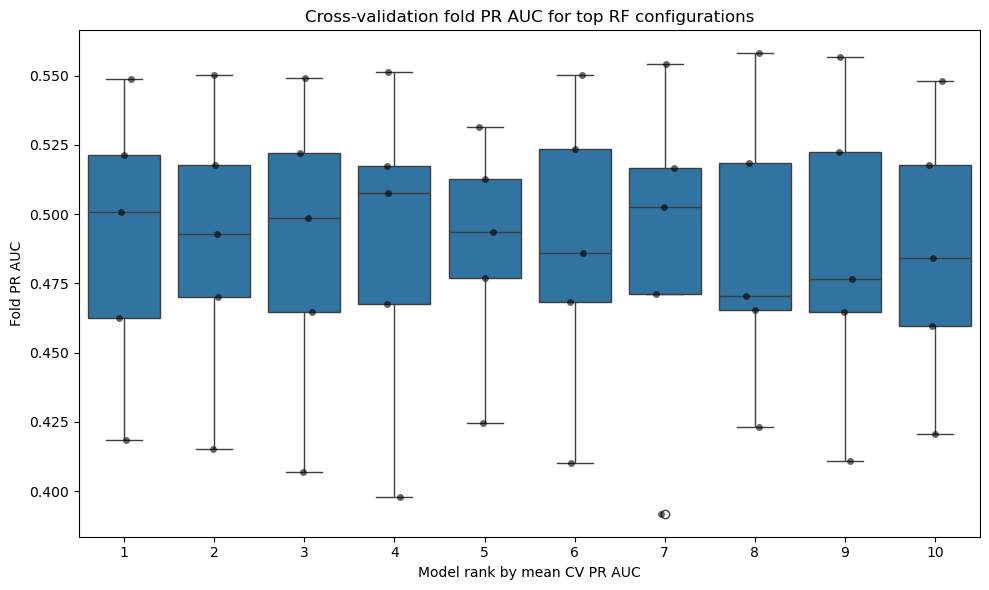

In [ ]:
rf_results = pd.DataFrame(rf_search_refined.cv_results_)

# get top 10 configs by mean CV PR AUC
top = rf_results.sort_values("mean_test_score", ascending=False).head(10).copy()
top["model_rank"] = range(1, len(top) + 1)

fold_cols = [c for c in rf_results.columns if c.startswith("split") and c.endswith("_test_score")]

top_long = top.melt(
    id_vars=["model_rank", "mean_test_score"],
    value_vars=fold_cols,
    var_name="fold",
    value_name="pr_auc"
)

plt.figure(figsize=(10, 6))
sns.boxplot(data=top_long, x="model_rank", y="pr_auc")
sns.stripplot(data=top_long, x="model_rank", y="pr_auc", color="black", alpha=0.6)

plt.xlabel("Model rank by mean CV PR AUC")
plt.ylabel("Fold PR AUC")
plt.title("Cross-validation fold PR AUC for top RF configurations")
plt.tight_layout()
plt.show() # points are jittered for visibility

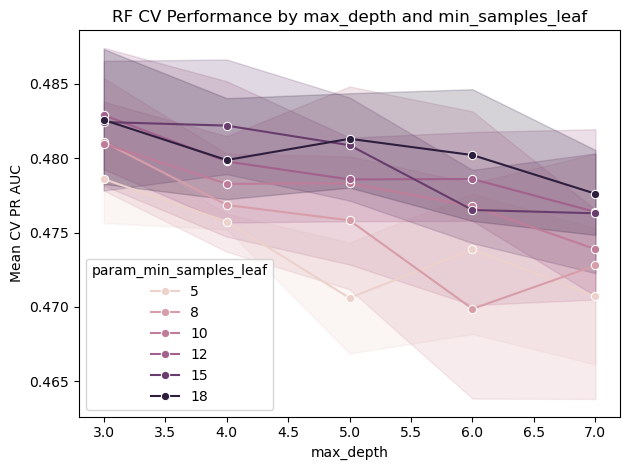

In [41]:
sns.lineplot(
    data=rf_results,
    x="param_max_depth",
    y="mean_test_score",
    hue="param_min_samples_leaf",
    marker="o"
)

plt.ylabel("Mean CV PR AUC")
plt.xlabel("max_depth")
plt.title("RF CV Performance by max_depth and min_samples_leaf")
plt.tight_layout()
plt.show()

## Metrics on The Training Data Itself for the Best Model

In [32]:
best_rf = rf_search_refined.best_estimator_
y_train_pred = best_rf.predict(x_train)

In [33]:
from sklearn import metrics
from sklearn.metrics import classification_report

target_names = ['No Chronic Heart Failure', 'Chronic Heart Failure']
print(classification_report(y_train, y_train_pred, target_names=target_names))

                          precision    recall  f1-score   support

No Chronic Heart Failure       0.82      0.99      0.89       988
   Chronic Heart Failure       0.87      0.23      0.36       286

                accuracy                           0.82      1274
               macro avg       0.84      0.61      0.63      1274
            weighted avg       0.83      0.82      0.77      1274



* The model shows very high recall for the majority class (0.99), indicating it almost always correctly identifies patients without CHF.
* For the CHF class, precision is high (0.87) but recall is low (0.23), meaning predicted CHF cases are usually correct, but many true CHF cases are missed
    * The model is therefore conservative in predicting the positive class, favoring fewer false positives at the cost of more false negatives.
    * perhaps a lowered threshold for model prediction could improve recall (y_proba >= 0.3 instead of 0.5)

* The gap between classes reflects the class imbalance and the model’s regularization, which biases predictions toward the majority class.

In [34]:
cnf_matrix = metrics.confusion_matrix(y_train, y_train_pred)
cnf_matrix = pd.DataFrame(cnf_matrix)
cnf_matrix.columns = ['predicted_no_CHF', 'predicted_CHF']
cnf_matrix.index = ['true_no_CHF', 'true_CHF']
cnf_matrix

,predicted_no_CHF,predicted_CHF
true_no_CHF,978,10
true_CHF,221,65


In [35]:
# dir(best_rf)

best_rf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': 3,
 'max_features': 0.5,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 18,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 300,
 'n_jobs': 8,
 'oob_score': False,
 'random_state': 321,
 'verbose': 0,
 'warm_start': False}

In [37]:
feature_names = x_train.columns
# Compute the variable importance
importances = best_rf.feature_importances_
dict_importance = {k:np.round(v,3) for (k,v) in zip(feature_names, importances)}
# Print the variable importance
print(dict_importance)

{'AGE': np.float64(0.069), 'SEX': np.float64(0.003), 'INF_ANAM': np.float64(0.002), 'IBS_POST': np.float64(0.002), 'GB': np.float64(0.004), 'endocr_01': np.float64(0.029), 'S_AD_ORIT': np.float64(0.019), 'D_AD_ORIT': np.float64(0.011), 'O_L_POST': np.float64(0.001), 'MP_TP_POST': np.float64(0.01), 'NA_BLOOD': np.float64(0.007), 'K_BLOOD': np.float64(0.01), 'L_BLOOD': np.float64(0.019), 'ant_im': np.float64(0.002), 'lat_im': np.float64(0.001), 'inf_im': np.float64(0.001), 'post_im': np.float64(0.0), 'ritm_ecg_p_01': np.float64(0.014), 'any_pulmonary_disease': np.float64(0.029), 'any_arrhythmia': np.float64(0.002), 'any_conduction_block': np.float64(0.001), 'ROE_log': np.float64(0.012), 'ALT_BLOOD_log': np.float64(0.015), 'AST_BLOOD_log': np.float64(0.016), 'ZSN_A_recode_mild': np.float64(0.538), 'ZSN_A_recode_missing': np.float64(0.022), 'ZSN_A_recode_moderate_severe': np.float64(0.01), 'ZSN_A_recode_none': np.float64(0.131), 'time_bin_early': np.float64(0.001), 'time_bin_intermediate':

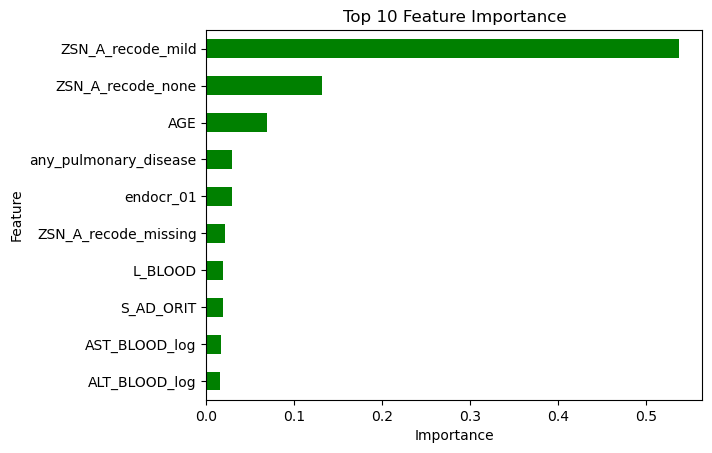

In [ ]:
feature_imp = pd.Series(best_rf.feature_importances_, index=x_train.columns)

# subset to top 10 features for better visualization
top10 = feature_imp.sort_values(ascending=False).head(10)

top10.sort_values().plot.barh(color='green')  # sort for horizontal plot
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importance");

## Evaluating Model Performance on Test Set